# **SENTIMENT ANALYSIS ON FLIPKART PRODUCT REVIEW**

In [ ]:
#Import libraries

from google.colab import drive
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from nltk import PorterStemmer, WordNetLemmatizer
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#To mount drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#For tokenisation, to reduce noise in the dataset and convert words to their base form.

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Isibor Esther Mini Project 3 Assignment/Dataset-SA.csv")

In [ ]:
#To.display the first five rows of the dataset

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [ ]:
#To check the number of rows and columns in the dataset

print(df.shape)

(205052, 6)


The output above shows that the dataset contains Two hundred and five thousand and fifty two rows and six columns.

In [ ]:
#To get a summary of the dataset including the data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None


From the above we can see that both review and summary both have missing values in their columns.

In [ ]:
#To display all the column names in the dataset

print(df.columns.tolist())

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


In [ ]:
#To check the distribution of sentiment classes in the dataset

print(df["Sentiment"].value_counts())

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


The output shows that most reviews are positive, followed by negative and neutral reviews. This shows that the dataset is imbalanced, with a higher number of positive reviews compared to other classes.

In [ ]:
#To check for the specific number of missing values in each columns

df.isna().sum()

,0
product_name,0
product_price,0
Rate,0
Review,24664
Summary,11
Sentiment,0


The output shows that the Review column has a significant number of missing values, while the Summary column has 11 missing entries which is very few.

In [ ]:
#To check for the number of duplicate rows in the dataset

df.duplicated().sum()

np.int64(34375)

From the output, there are 34,375 duplicate rows or entries in the dataset and these duplicates would be removed in order to avoid bias when training the model.

In [ ]:
#To remove the duplicate entries in the dataset

df = df.drop_duplicates()

In [ ]:
#To confirm that there are no more duplicate entries in the dataset

df.duplicated().sum()

np.int64(0)

In [ ]:
#To drop the entire rows with missing entries

df = df.dropna()

In [ ]:
#To confirm that there are no more missing values

df.isna().sum()

,0
product_name,0
product_price,0
Rate,0
Review,0
Summary,0
Sentiment,0


In [ ]:
#To check how many rows and columns are in the datsset after dropping the duplicates and missing values

print(df.shape)

(154467, 6)


After removing duplicates and missing entries, we now have 154,467 rows and 6 columns in the dataset.

# **PREPROCESSING**

In [ ]:
#Converting all text to lowercase
df["cleaned_text"] = df["Summary"].str.lower()

#To remove punctuation and special characters
df["cleaned_text"] = df["cleaned_text"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', ' ', x))

#Tokenization - splitting sentences into words
df["tokens"] = df["cleaned_text"].apply(word_tokenize)

#To remove stop words and lematisation
df["cleaned_text"] = df["tokens"].apply(
    lambda tokens: " ".join([
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2]))

A new column called cleaned_text was created to store the preprocessed version of the text after cleaning.

In [ ]:
#To view the first five rows of the cleaned_text column in order to verify that the preprocessing was successful.

df["cleaned_text"].head()

,cleaned_text
0,great cooler excellent air flow price amazing ...
1,best budget fit cooler nice cooling
2,quality good power air decent
3,bad product fan
4,product


The above output shows that the text has been converted to lowercase, punctuation has been removed, stopwords have been removed, and the remaining words are cleaned and ready for analysis.

In [ ]:
#To display sample of cleaned_text with sentiment and rate in order to better understand the data

print(df.head(3)[["cleaned_text", "Sentiment", "Rate"]])

                                        cleaned_text Sentiment Rate
0  great cooler excellent air flow price amazing ...  positive    5
1                best budget fit cooler nice cooling  positive    5
2                      quality good power air decent  positive    3


In [ ]:
#To display one example review from each sentiment category.

for sent in ["positive", "neutral", "negative"]:
    sample = df[df["Sentiment"] == sent]["cleaned_text"].iloc[0]
    print(f"\n{sent.upper()}:\n{sample}")


POSITIVE:
great cooler excellent air flow price amazing unbelievablejust love

NEUTRAL:
product

NEGATIVE:
bad product fan


In [ ]:
#Grouping words by sentiment category

positive_words = ' '.join(df[df['Sentiment'] == 'positive']['cleaned_text'])

negative_words = ' '.join(df[df['Sentiment'] == 'negative']['cleaned_text'])

neutral_words = ' '.join(df[df['Sentiment'] == 'neutral']['cleaned_text'])

I grouped the cleaned text data according to sentiment categories (positive, negative, and neutral) to prepare the text for further visualization using word clouds.

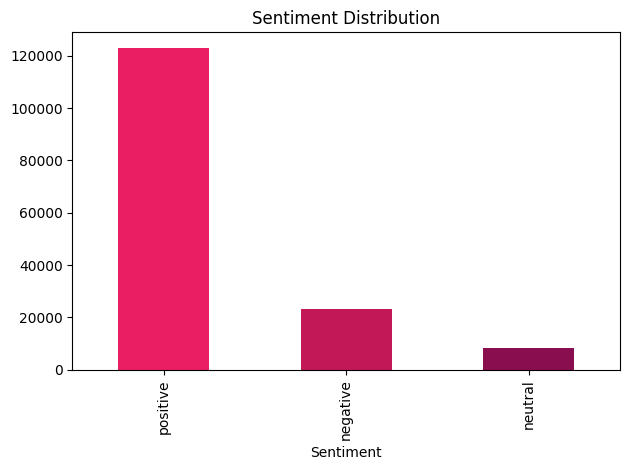

In [ ]:
#Creating a bar chart to visualise the sentiment category of the dataset

df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["#E91E63", "#C21858", "#880E4F"],
    title="Sentiment Distribution")

plt.tight_layout()
plt.show()

The bar chart shows that positive reviews are very much higher than negative and neutral reviews in the dataset. This indicates that most customers gave good feedback about the products.

The distribution also shows that the dataset is imbalanced, since the positive sentiment class contains far more entries than the other sentiment categories.

In [ ]:
#To identify frequent words that occur in each sentiment category

positive_split = Counter(positive_words.split()).most_common(10)

negative_split = Counter(negative_words.split()).most_common(10)

neutral_split = Counter(neutral_words.split()).most_common(10)

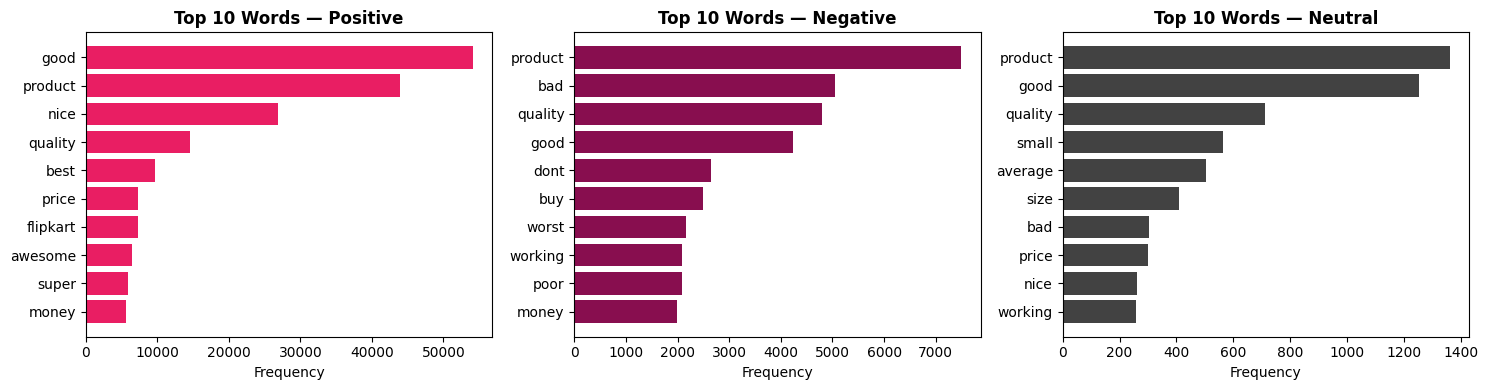

In [ ]:
#Visualising frequent words by sentiment

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sentiments = ['positive', 'negative', 'neutral']
colors = ['#E91E63', '#880E4F', '#424242']

for ax, sent, color in zip(axes, sentiments, colors):

    all_words = ' '.join(
        df[df['Sentiment'] == sent]['cleaned_text'])

    word_counts = Counter(all_words.split()).most_common(10)

    words, counts = zip(*word_counts)

    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)

    ax.set_title(f'Top 10 Words — {sent.title()}',
                 fontweight='bold')

    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
#Grouping positive, negative and neutral reviews into single text string respectively
positive_text = ' '.join(df[df['Sentiment'] == 'positive']['cleaned_text'])
negative_text = ' '.join(df[df['Sentiment'] == 'negative']['cleaned_text'])
neutral_text = ' '.join(df[df['Sentiment'] == 'neutral']['cleaned_text'])

# **GENERATING WORD CLOUDS**

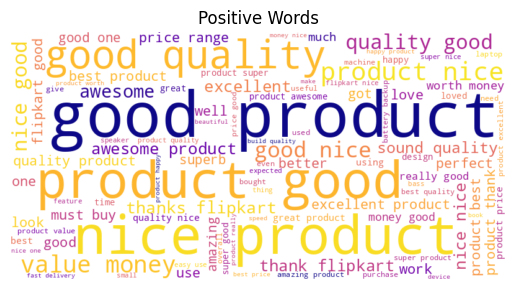

In [ ]:
#Positive Word Cloud

wordcloud_positive = WordCloud(width=800,height=400,
    background_color="white",colormap="plasma",
    max_words=100,min_font_size=10).generate(positive_text)

ax = plt.axes()
ax.imshow(wordcloud_positive, interpolation="bilinear")
ax.axis("off")
ax.set_title("Positive Words")
plt.show()

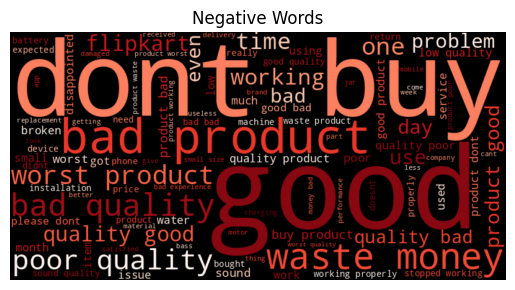

In [ ]:
#Negative Word Cloud

wordcloud_negative = WordCloud(width=800,height=400,
    background_color="black",colormap="Reds",
    max_words=100,min_font_size=10).generate(negative_text)

ax = plt.axes()
ax.imshow(wordcloud_negative, interpolation="bilinear")
ax.axis("off")
ax.set_title("Negative Words")
plt.show()

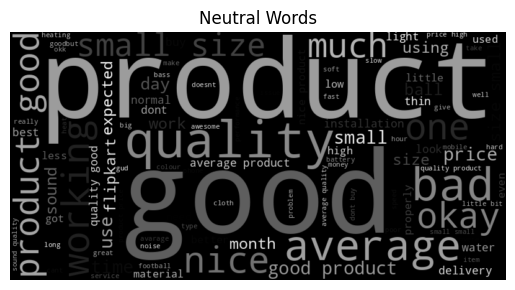

In [ ]:
#Neutral Word Cloud

wordcloud_neutral = WordCloud(width=800,height=400,
    background_color="black",colormap="grey",
    max_words=100,min_font_size=10).generate(neutral_text)

ax = plt.axes()
ax.imshow(wordcloud_neutral, interpolation="bilinear")
ax.axis("off")
ax.set_title("Neutral Words")
plt.show()

# **Feature Extraction using TF-IDF (Term Frequency–Inverse Document Frequency)**

In [ ]:
# TF-IDF

X = df["cleaned_text"]
y = df["Sentiment"]

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
# Fit TF-IDF on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Check shapes
print(f"Train matrix size: {X_train_tfidf.shape}")
print(f"Test matrix size: {X_test_tfidf.shape}")

Train matrix size: (123573, 5000)
Test matrix size: (30894, 5000)


# **Logistic Regression Model**

In [ ]:
LR_model = LogisticRegression(class_weight='balanced', random_state =42, max_iter=1000)
LR_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = LR_model.predict(X_test_tfidf)

# **To Evaluate Performance**

In [ ]:
#To check the accuracy score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.830743833754127


The accuracy score shows that the model correctly predicts about 83% of all reviews but accuracy alone would not be enough to evaluate the performance so I would be checking other evaluation metrics.

In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 3520   719   432]
 [  308  1142   211]
 [ 1275  2284 21003]]


**Negative class**

3520 negative reviews were correctly predicted as negative

719 negative reviews were wrongly predicted as neutral

432 negative reviews were wrongly predicted as positive.


**Neutral class**

308 neutral reviews were predicted as negative

1142 neutral reviews were correctly predicted as neutral

211 neutral reviews were predicted as positive.


**Positive class**

1275 positive reviews were predicted as negative

2284 positive reviews were predicted as neutral

21003 positive reviews were correctly predicted as positive


Overall, the model performs best on the positive class with 21003 correct predictions, reasonably on the negative class with 3520 correct predictions and performs weakest on the neutral class with 1142 correct predictions.

In [ ]:
#Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.69      0.75      0.72      4671
     neutral       0.28      0.69      0.39      1661
    positive       0.97      0.86      0.91     24562

    accuracy                           0.83     30894
   macro avg       0.65      0.77      0.67     30894
weighted avg       0.89      0.83      0.85     30894



**Positive class**

Precision: 0.97

Recall: 0.86

F1-score: 0.91

This shows that the model is good at identifying positive reviews and
this can be expected because positive class has the most data (24562 samples)

**Negative class**

Precision: 0.69

Recall: 0.75

F1-score: 0.72

This indicates that the model performs reasonably okay.
It correctly identifies most negative reviews but still confuses some with other classes.

**Neutral class**

Precision: 0.28 (low)

Recall: 0.69

F1-score: 0.39

This shows that the model struggles with neutral reviews.
It detects 69% of neutrals which is an okay recall but makes many incorrect neutral predictions which is observed by the low precision. This could be because
neutral text is less strong in the dataset and the wordings of neutral text overlaps with positive/negative wording.

# **CONCLUSION**

This project focused on performing sentiment analysis on Flipkart product reviews using machine learning techniques.


The dataset was first explored to understand its structure, including product details, ratings, reviews, and sentiment labels. Data cleaning was then carried out by removing missing values and duplicate entries to ensure data quality.


Text preprocessing was applied to prepare the review text for analysis. This included converting text to lowercase, removing special characters, tokenization, stopword removal, and lemmatization. The cleaned text was then used for further analysis.


Exploratory Data Analysis (EDA) was performed to understand sentiment distribution and identify common words in each sentiment category using visualizations such as bar charts and word clouds.


For feature extraction, TF-IDF (Term Frequency–Inverse Document Frequency) was used to convert textual data into numerical format suitable for machine learning models. The dataset was then split into training and testing sets.


A Logistic Regression model with class balancing was trained on the TF-IDF features to handle the class imbalance in the dataset. The model was evaluated using accuracy, confusion matrix, and classification report.


The model achieved an accuracy of approximately 83%, performing strongly on positive reviews, reasonably on negative reviews, and showing lower performance on neutral reviews.

In [ ]:
#To save my cleaned dataset

df.to_csv("cleaned_sentiment_data.csv", index=False)